In [ ]:
import pandas as pd
import numpy as np
import os
import optuna
import shap
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GroupKFold
from sklearn.metrics import r2_score
from sklearn.cluster import KMeans
from scipy.stats import spearmanr
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
def analyze_importance(model, X, target_name):
    print(f"\n{'='*30}\nAnalysis for {target_name}\n{'='*30}")

    # 1. CatBoost Internal Importance (Fast)
    feature_importance = model.get_feature_importance(type='FeatureImportance')
    fi_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': feature_importance
    }).sort_values(by='Importance', ascending=False)

    print(f"Top 10 Features (Internal):")
    print(fi_df.head(10))

    # 2. SHAP Values (The 'Why')
    # Use a sample for speed if dataset is large
    X_sample = X.sample(min(1000, len(X)), random_state=42)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    # Plotting
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    # Global Importance Plot
    fi_df.head(20).plot(kind='barh', x='Feature', y='Importance', ax=plt.gca(), color='skyblue')
    plt.title(f"Internal Importance: {target_name}")
    plt.gca().invert_yaxis()

    plt.subplot(1, 2, 2)
    # SHAP Summary
    shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
    plt.title(f"SHAP Importance: {target_name}")

    plt.tight_layout()
    plt.show()

    return fi_df

# ==========================================
# 1. CONFIGURATION & PATHS
# ==========================================
class Config:
    BASE_DIR = '/content/drive/MyDrive/EY_Datathon_DWS'
    SEED = 85
    N_FOLDS = 5
    TARGETS = [
        'Total Alkalinity',
        'Electrical Conductance',
        'Dissolved Reactive Phosphorus'
    ]
    # DWS features to prioritize
    DWS_FEATS = ['dws_TAL', 'dws_EC', 'dws_PO4_P', 'dws_pH', 'dws_Ca', 'dws_Mg', 'dws_Na', 'dws_Cl', 'dws_SO4']

# ==========================================
# 2. ENGINEERING UTILITIES
# ==========================================
def engineer_features(df):
    """
    Apply cyclical encoding and water quality specific ratios.
    """
    temp_df = df.copy()

    # 2.2 Remote Sensing Ratios (NDVI, etc)
    # Note: NIR and Green are usually available. B4 (Red) is highly recommended to fetch.
    if 'nir' in temp_df.columns and 'green' in temp_df.columns:
        temp_df['nir_green_ratio'] = temp_df['nir'] / (temp_df['green'] + 1e-6)

    # 2.3 Log-transform highly skewed features
    skewed_feats = ['Popdens_00', 'SOC', 'dist_km']
    for feat in skewed_feats:
        if feat in temp_df.columns:
            temp_df[f'log_{feat}'] = np.log1p(temp_df[feat])

    return temp_df

def prune_features(X, correlation_threshold=0.95):
    """
    Remove multicollinear and zero-variance features.
    """
    # Remove constant columns
    X = X.loc[:, X.nunique() > 1]

    # Identify highly correlated features
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > correlation_threshold)]

    print(f"Dropped {len(to_drop)} features due to high correlation (> {correlation_threshold})")
    return X.drop(columns=to_drop)

# ==========================================
# 3. DATA LOADING & SPATIAL CV SETUP
# ==========================================
print("Loading datasets...")
train_full = pd.read_csv(f'{Config.BASE_DIR}/train_ALL+reliability.csv') # Your DWS-matched file
test_full = pd.read_csv(f'{Config.BASE_DIR}/test_ALL+reliability.csv')

# Cluster stations for Spatial CV
stations = train_full.groupby(['Latitude', 'Longitude']).size().reset_index()
kmeans = KMeans(n_clusters=Config.N_FOLDS, random_state=Config.SEED, n_init=10)
stations['spatial_cluster'] = kmeans.fit_predict(stations[['Latitude', 'Longitude']])

train_full = train_full.merge(stations[['Latitude', 'Longitude', 'spatial_cluster']],
                              on=['Latitude', 'Longitude'], how='left')

# Pre-process
train_eng = engineer_features(train_full)
test_eng = engineer_features(test_full)

# ==========================================
# 4. TARGET-SPECIFIC MODELING (OPTUNA)
# ==========================================
def objective(trial, X, y, groups):
    param = {
        "iterations": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "depth": trial.suggest_int("depth", 3, 5), # Shallow trees generalize better
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 2.0, 20.0), # Higher reg = less noise
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 100), # Prevents small outliers
        "random_strength": trial.suggest_float("random_strength", 1e-1, 10.0, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "grow_policy": "SymmetricTree",
        "loss_function": "RMSE",
        "random_seed": Config.SEED,
        "verbose": False,
        "task_type": "CPU" # Switch to GPU if available
    }

    gkf = GroupKFold(n_splits=Config.N_FOLDS)
    scores = []

    for train_idx, val_idx in gkf.split(X, y, groups=groups):
        model = CatBoostRegressor(**param)
        model.fit(X.iloc[train_idx], y.iloc[train_idx],
                  eval_set=(X.iloc[val_idx], y.iloc[val_idx]),
                  early_stopping_rounds=50)
        preds = model.predict(X.iloc[val_idx])
        preds = model.predict(X.iloc[val_idx])
        # If target is DRP, we must reverse the log1p to calculate a real R2
        if "Phosphorus" in y.name:
            actuals = np.expm1(y.iloc[val_idx])
            preds = np.expm1(preds)
            scores.append(r2_score(actuals, preds))
        else:
            scores.append(r2_score(y.iloc[val_idx], preds))

    return np.mean(scores)

# ==========================================
# 5. EXECUTION PIPELINE (FIXED)
# ==========================================
final_preds = {}
models = {}  # Store models here to fix the NameError

# Define feature set
# ADD 'Latitude' and 'Longitude' to the ignore list
ignore_cols = Config.TARGETS + ['Latitude', 'Longitude', 'STAT_ID', 'Sample Date',
                               'spatial_cluster', 'geometry', '_merge_terra',
                               '_merge_landsat', 'Latitude_glorich',
                               'Longitude_glorich', 'date', 'dws_1st','Impute_Method']
features = [c for c in train_eng.columns if c not in ignore_cols]

X_train_clean = prune_features(train_eng[features])
X_train_clean.drop(columns=['P_modified_same','dws_P_reliability'], inplace=True)
X_test_clean = test_eng[X_train_clean.columns]

for target in Config.TARGETS:
    print(f"\n--- Optimizing for {target} ---")

    y = train_eng[target]
    y_train = np.log1p(y) if target == 'Dissolved Reactive Phosphorus' else y

    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(trial, X_train_clean, y_train, train_eng['spatial_cluster']), n_trials=20)

    print(f"Best Score: {study.best_value}")

    # Train final model with best params and STORE IT
    final_model = CatBoostRegressor(**study.best_params, iterations=1500, verbose=0)
    final_model.fit(X_train_clean, y_train)
    models[target] = final_model # <--- This is the fix

    preds = final_model.predict(X_test_clean)
    if target == 'Dissolved Reactive Phosphorus':
        preds = np.expm1(preds)

    final_preds[target] = np.clip(preds, 0, None)

# ==========================================
# 7. GENERATE SUBMISSION
# ==========================================
submission = pd.DataFrame({
    'Latitude': test_full['Latitude'],
    'Longitude': test_full['Longitude'],
    'Sample Date': test_full['Sample Date'],
    'Total Alkalinity': final_preds['Total Alkalinity'],
    'Electrical Conductance': final_preds['Electrical Conductance'],
    'Dissolved Reactive Phosphorus': final_preds['Dissolved Reactive Phosphorus']
})

# Hybrid TAL adjustment: If distance to DWS is extremely low, trust DWS measurement
dws_tal = test_full['dws_TAL'].values
submission['Total Alkalinity'] = np.where(
    np.isfinite(dws_tal),
    dws_tal,
    test_full['Total Alkalinity']
)


submission.to_csv(f'{Config.BASE_DIR}/submission_reliabilityOfDWS_temp1_all_features.csv', index=False)
print("Submission saved.")
# ==========================================
# 8. FEATURE IMPORTANCE ANALYSIS (FIXED)
# ==========================================
# Use X_train_clean as it contains the final feature set
for target in Config.TARGETS:
    if target in models:
        df = analyze_importance(models[target], X_train_clean, target)
        print(df[df['Importance']<=3])

Loading datasets...


[I 2026-03-13 11:02:41,679] A new study created in memory with name: no-name-9be2c900-9357-4df0-aac2-fd427c28680b


Dropped 7 features due to high correlation (> 0.95)

--- Optimizing for Total Alkalinity ---


[I 2026-03-13 11:02:50,321] Trial 0 finished with value: 0.982308498446268 and parameters: {'learning_rate': 0.03300843125302317, 'depth': 4, 'l2_leaf_reg': 19.162762482801153, 'min_data_in_leaf': 100, 'random_strength': 0.202763106674923, 'bagging_temperature': 0.9663201546854757}. Best is trial 0 with value: 0.982308498446268.
[I 2026-03-13 11:03:17,718] Trial 1 finished with value: 0.7587486414589394 and parameters: {'learning_rate': 0.001118143877756733, 'depth': 4, 'l2_leaf_reg': 3.2867114449566923, 'min_data_in_leaf': 29, 'random_strength': 0.1405857164308224, 'bagging_temperature': 0.8550826770205174}. Best is trial 0 with value: 0.982308498446268.
[I 2026-03-13 11:03:38,112] Trial 2 finished with value: 0.9570522018090546 and parameters: {'learning_rate': 0.003037143612205517, 'depth': 3, 'l2_leaf_reg': 16.441467596537947, 'min_data_in_leaf': 71, 'random_strength': 0.1935009421729505, 'bagging_temperature': 0.6744625480121414}. Best is trial 0 with value: 0.982308498446268.
[I 

high error: 39
high error: 226
high error: 1476


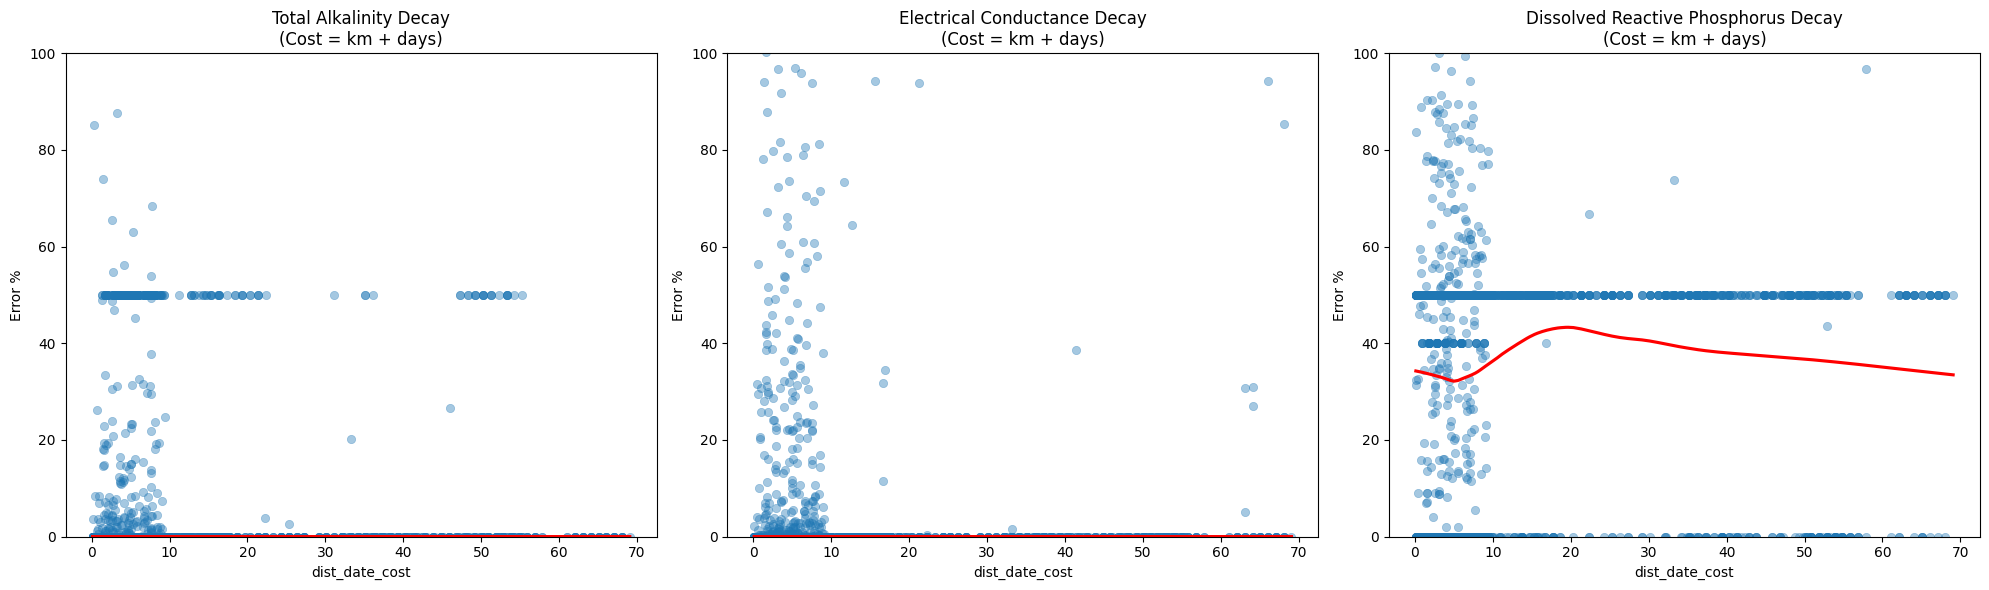


--- Reliability Report (<5% Error) ---
Total Alkalinity: 94.81% of samples are exact matches (within 5%)
Electrical Conductance: 93.72% of samples are exact matches (within 5%)
Dissolved Reactive Phosphorus: 31.85% of samples are exact matches (within 5%)


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_unit_corrected_dws(df):
    # 1. Apply Unit Corrections
    # EC: DWS (mS/m) -> Competition (uS/cm or similar scale check)
    # PO4: DWS (mg/L) -> Competition (ug/L)
    df['dws_EC_scaled'] = df['dws_EC'] * 10
    df['dws_PO4_scaled'] = df['dws_PO4_P'] * 1000

    # 2. Calculate Combined Spatio-Temporal Distance
    # We use a simple 'Cost' metric: 1km = 1 day of 'decay'
    df['dist_date_cost'] = df['dist_km'] + df['date_diff_days'].abs()

    targets = {
        'Total Alkalinity': 'dws_TAL',
        'Electrical Conductance': 'dws_EC_scaled',
        'Dissolved Reactive Phosphorus': 'dws_PO4_scaled'
    }

    plt.figure(figsize=(20, 6))

    for i, (target, dws_col) in enumerate(targets.items()):
        # Calculate Absolute Percentage Error (MAPE) for better scaling
        # Adding 1e-6 to avoid division by zero
        df[f'{target}_error'] = np.abs(df[target] - df[dws_col]) / (df[target] + 1e-6) * 100

        plt.subplot(1, 3, i+1)
        # Filter out extreme outliers for better visualization
        plot_df = df
        print(f"high error: {len(df[df[f'{target}_error'] > 100])}")

        sns.scatterplot(
            data=plot_df,
            x='dist_date_cost',
            y=f'{target}_error',
            alpha=0.4,
            edgecolor=None
        )

        # Add a trend line to see the 'Trust Decay'
        sns.regplot(
            data=plot_df,
            x='dist_date_cost',
            y=f'{target}_error',
            scatter=False,
            color='red',
            lowess=True
        )

        plt.title(f'{target} Decay\n(Cost = km + days)')
        plt.ylim(0, 100)
        plt.ylabel('Error %')

    plt.tight_layout()
    plt.show()

    # 3. Decision Matrix: Percent of samples with < 5% error
    print("\n--- Reliability Report (<5% Error) ---")
    for target in targets.keys():
        pct = (df[f'{target}_error'] < 5).mean() * 100
        print(f"{target}: {pct:.2f}% of samples are exact matches (within 5%)")

# Run diagnostic
analyze_unit_corrected_dws(train_full)